# 02 Disengagement Model

This notebook trains a Week 6 classifier for `Withdrawn/Fail = 1` versus `Pass/Distinction = 0`. The model is statistically evaluated with precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix, and calibration. For product use, the output is framed as three intervention tiers instead of a broad urgent alert: a top-risk high-touch support queue, a light-touch behavioural nudge group, and a monitoring group.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_loader import OUT_DIR, WEEK_CUTOFF, audit_and_clean_data, ensure_dirs, load_data
from evaluation import plot_model_outputs
from features import build_weekly_base_features, make_enrollment_split
from modeling import build_week6_model_dataset, train_risk_model
from scoring import apply_engagement_score, derive_engagement_weights

pd.set_option("display.max_columns", 140)
sns.set_theme(style="whitegrid")
ensure_dirs()


## 1. Rebuild The Leakage-Safe Week 6 Dataset

The prediction point is Week 6. The feature table below uses registration/context fields, pre-start VLE activity, and Week 1-6 behaviour only. Final outcomes are used only as the supervised target.


In [2]:
raw_data = load_data()
data, audits = audit_and_clean_data(raw_data)
weekly_base = build_weekly_base_features(data)
split = make_enrollment_split(weekly_base)
weights, weight_rationale = derive_engagement_weights(weekly_base, split)
weekly = apply_engagement_score(weekly_base, weights)
weekly.to_csv(OUT_DIR / "weekly_engagement_features.csv", index=False)

audits["leakage"]


,candidate_feature,available_by_week6,used,reason
0,Pre-start VLE activity (negative dates),Yes,Yes,Observed before day 0; reflects eagerness to b...
1,Week 1-6 VLE clicks,Yes,Yes,Observed before the Week 6 prediction point.
2,Week 1-6 active days,Yes,Yes,Observed before the Week 6 prediction point.
3,Week 1-6 activity diversity,Yes,Yes,Observed before the Week 6 prediction point.
4,Early non-exam assessment submissions,Yes,Yes,Only due/submitted work by Week 6 is used.
5,Student demographics/context,Yes,Yes,Known at registration or course enrolment.
6,Engagement score,Yes,Yes,Computed from Week 1-6 behavior using train-de...
7,Final result,No,Target only,Used only to train/evaluate the supervised label.
8,Final exam score,No,No,Not available by Week 6.
9,Full-semester total clicks,No,No,Would leak future engagement behavior.


In [3]:
model_df = build_week6_model_dataset(weekly, data)
print(model_df.shape)
model_df.head()


(32593, 119)


,code_module,code_presentation,id_student,weekly_clicks_6,weekly_clicks_norm_6,active_days_last_7_6,study_regularity_score_6,click_gini_6,burstiness_score_6,week_to_week_volatility_6,material_active_days_6,recent_material_active_days_2w_6,material_click_share_6,content_click_ratio_6,quiz_click_ratio_6,homepage_dependency_ratio_6,forum_clicks_6,forum_active_days_6,forum_click_ratio_6,social_click_ratio_6,unique_sites_6,activity_entropy_6,activity_diversity_6,recent_clicks_2w_6,recent_activity_drop_6,click_trend_3w,consistency_rate_6,zero_click_weeks_6,days_since_last_click_6,longest_inactive_gap_6,inactive_last_7_days_6,inactive_last_14_days_6,first_click_day_6,on_schedule_click_ratio_6,ahead_click_ratio_6,catchup_click_ratio_6,avg_material_lag_6,planned_material_coverage_6,pace_metadata_coverage_ratio_6,assessment_submitted_ratio_6,missed_assessments_6,submitted_count_6,late_submission_count_6,early_submission_count_6,pre_assessment_clicks_7d_6,cram_ratio_6,prep_started_days_before_due_6,post_bad_score_recovery_clicks_6,punctuality_ratio_6,low_weight_completion_ratio_6,starting_early_score_6,avg_score_so_far_6,engagement_score_6,pre_start_clicks_6,pre_start_clicks_log_6,pre_start_active_days_6,days_before_start_6,pre_start_material_clicks_6,pre_start_flag_6,pre_start_proactivity_6,final_result,module_code,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,profile_activity_clicks_6,resource_clicks_6,resource_ratio_6,oucontent_clicks_6,oucontent_ratio_6,questionnaire_clicks_6,questionnaire_ratio_6,dataplus_clicks_6,dataplus_ratio_6,ouwiki_clicks_6,ouwiki_ratio_6,forumng_clicks_6,forumng_ratio_6,repeat_attempt_flag,high_credit_load_flag,low_imd_flag,active_week_ratio_6,early_submission_ratio_6,high_credit_low_engagement,motivation_proxy,education_level_ord,age_band_ord,mature_student_flag,young_student_flag,imd_midpoint,imd_missing_flag,high_imd_flag,attempt_count_capped,multiple_attempts_flag,credit_load_z_by_module,credits_per_active_day_6,higher_education_flag,lower_education_flag,prepared_mature_high_imd_profile,younger_lower_education_low_imd_profile,profile_group,week6_archetype,archetype_early_disengager_flag,archetype_burst_flag,archetype_compliance_flag,archetype_proactive_flag,credits_x_low_engagement,education_x_assessment_completion,age_x_study_regularity,attempts_x_low_engagement,low_imd_x_resource_ratio,higher_edu_x_oucontent_ratio,younger_lower_edu_x_resource_ratio,prepared_profile_x_questionnaire_ratio,risk_label
0,AAA,2013J,11391,389.0,0.486510,12.0,0.285714,0.221826,0.627161,43.308968,10.0,3.0,0.553514,0.553514,0.0,0.128383,78.0,6.0,0.151436,0.151436,46.0,1.091008,3.666667,86.0,-1.000000,30.0,0.833333,1,1.0,9.0,0,0,0.0,0.333333,0.000000,0.166667,0.166667,1.000000,0.149417,1.0,0.0,1.0,0.0,1.0,100.0,0.166667,2.0,0.0,1.0,1.0,1.0,78.0,50.4,98.0,4.595120,1.0,5.0,89.0,1,0.303916,Pass,AAA,M,HE Qualification,90-100%,55<=,0,240,N,325.0,9.0,0.027692,238.0,0.732308,0.0,0.0,0.0,0.0,0.0,0.0,78.0,0.240000,0,1,0,0.833333,1.0,1,0.0,3,2,1,0,95.0,0,1,0,0,3.548823,20.000000,1,0,1,0,prepared_mature_high_imd,mixed_engagement,0,0,0,0,119.04,3.0,0.571429,0.0,0.0,0.732308,0.0,0.0,0
1,AAA,2013J,28400,410.0,0.507180,15.0,0.357143,0.266677,0.612315,32.159757,13.0,2.0,0.379234,0.379234,0.0,0.188192,136.0,7.0,0.265907,0.265907,55.0,1.575840,4.000000,75.0,1.000000,-28.5,0.833333,1,7.0,7.0,1,0,0.0,0.186275,0.147059,0.000000,-0.119048,1.000000,0.055108,1.0,0.0,1.0,1.0,0.0,37.0,0.000000,3.0,0.0,0.0,1.0,0.0,70.0,27.3,215.0,5.375278,7.0,10.0,96.0,1,0.766319,Pass,AAA,F,HE Qualification,20-30%,35-55,0,60,N,258.0,0.0,0.000000,122.0,0.472868,0.0,0.0,0.0,0.0,0.0,0.0,136.0,0.527132,0,0,1,0.833333,0.0,0,0.0,3,1,1,0,25.0,0,0,0,0,0.000000,4.000000,1,0,0,0,higher_education,perfectionist_procrastinator,0,0,0,0,43.62,3.0,0.357143,0.0,0.0,0.472868,0.0,0.0,0
2,AAA,2013J,30268,179.0,0.255657,6.0,0.142857,0.070324,0.160501,0.000000,4.0,0.0,0.111089,0.111089,0.0,0.051899,87.0,4.0,0.170344,0.170344,23.0,0.552417,1.666667,0.0

## 1.1 Week 6 Archetype And Profile Features

Task 2 now explicitly carries forward the Task 1 engagement logic. The model includes `engagement_score_6` plus a leakage-safe `week6_archetype` inferred only from behaviour available by Week 6. It also includes transformed student-context features: ordered education level, IMD midpoint, age order, module-normalized credit load, repeat-attempt indicators, resource-mix ratios, and interpretable interaction terms.

The archetype/profile risk-prior columns are computed from the training split only inside `split_model_data`, so they do not use test labels.

In [4]:
feature_catalog = pd.read_csv(OUT_DIR / "task2_feature_catalog.csv")
feature_catalog

,bucket,feature,reason
0,Engagement,engagement_score_6,Latest leakage-safe Week 6 engagement score fr...
1,Engagement,week6_archetype,Most likely Week 6 behavioural archetype using...
2,Engagement,week6_archetype_risk_prior,Train-only risk rate for each Week 6 archetype.
3,Preparedness,education_level_ord,Ordered education ladder to capture prior acad...
4,Preparedness,higher_education_flag,"HE-or-higher indicator, motivated by outcome g..."
5,Socioeconomic context,imd_midpoint,Numeric deprivation band midpoint; used as con...
6,Socioeconomic context,low_imd_flag,Lower IMD context flag.
7,Life stage,age_band_ord,Ordered age band.
8,Life stage,mature_student_flag,Mature student support-context flag.
9,Workload,credit_load_z_by_module,Credits normalized against peers in the same m...


In [5]:
archetype_counts = (
    model_df.groupby("week6_archetype")
    .agg(enrolments=("risk_label", "size"), observed_withdraw_fail_rate=("risk_label", "mean"))
    .sort_values("observed_withdraw_fail_rate", ascending=False)
)
archetype_counts

,enrolments,observed_withdraw_fail_rate
week6_archetype,,
early_disengager,9766,0.872210
struggling_repeater,378,0.711640
high_workload_risk,1919,0.614382
mixed_engagement,2978,0.472129
surface_compliance_engager,434,0.398618
sporadic_burst_engager,10727,0.355272
perfectionist_procrastinator,2998,0.324216
steady_engager,176,0.278409
proactive_engager,3217,0.258315


In [6]:
profile_counts = (
    model_df.groupby("profile_group")
    .agg(enrolments=("risk_label", "size"), observed_withdraw_fail_rate=("risk_label", "mean"))
    .sort_values("observed_withdraw_fail_rate", ascending=False)
)
profile_counts

,enrolments,observed_withdraw_fail_rate
profile_group,,
younger_lower_education_low_imd,2512,0.710987
low_imd,3579,0.568595
mixed_profile,21459,0.522205
higher_education,4041,0.452858
prepared_mature_high_imd,1002,0.350299


In [7]:
forbidden_tokens = ["final_result", "date_unregistration", "exam", "module_presentation_length"]
feature_columns = [c for c in model_df.columns if c not in ["risk_label", "final_result"]]
[c for c in feature_columns if any(token in c.lower() for token in forbidden_tokens)]


[]

## 2. Feature Screening For The Model

This is intentionally simple: we inspect correlations and feature distributions before model training. The goal is not to blindly add every possible variable, but to keep features that have a behavioural story and measurable signal.


In [8]:
numeric_cols = model_df.select_dtypes(include="number").columns.drop("risk_label")
correlations = (
    model_df[numeric_cols.tolist() + ["risk_label"]]
    .corr(numeric_only=True)["risk_label"]
    .drop("risk_label")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
correlations.head(20).to_frame("risk_correlation")


,risk_correlation
engagement_score_6,-0.516443
weekly_clicks_norm_6,-0.507111
assessment_submitted_ratio_6,-0.485747
active_week_ratio_6,-0.473320
consistency_rate_6,-0.473320
zero_click_weeks_6,0.473320
missed_assessments_6,0.452782
archetype_early_disengager_flag,0.451035
education_x_assessment_completion,-0.442650
activity_diversity_6,-0.440968


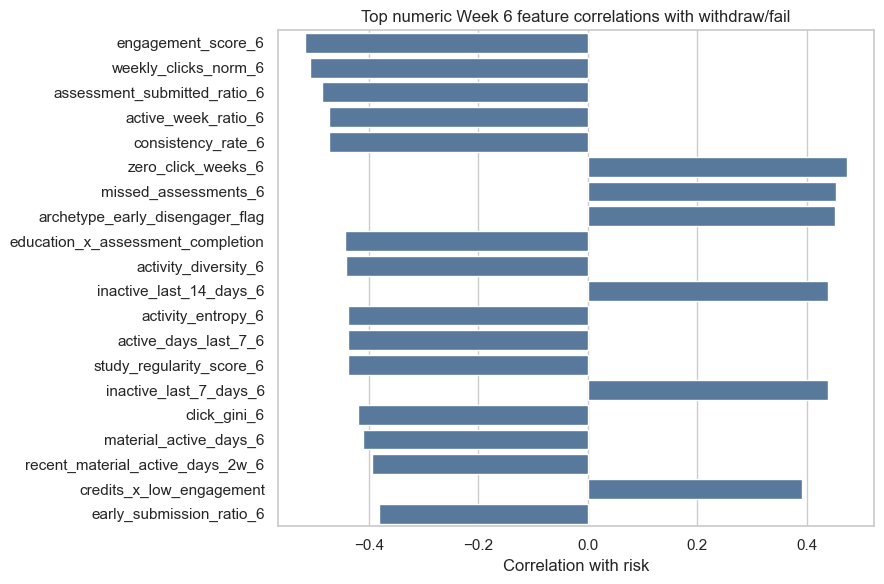

In [9]:
top_corr = correlations.head(20).reset_index()
top_corr.columns = ["feature", "risk_correlation"]
plt.figure(figsize=(9, 6))
sns.barplot(data=top_corr, y="feature", x="risk_correlation", color="#4C78A8")
plt.title("Top numeric Week 6 feature correlations with withdraw/fail")
plt.xlabel("Correlation with risk")
plt.ylabel("")
plt.tight_layout()


### Compact Behavioural Correlation Heatmap

To keep the feature set explainable, this heatmap focuses on core Week 6 behavioural features plus the risk label. The goal is to see which signals move with withdraw/fail risk and which signals are measuring similar behaviour. Strong target correlations are useful, but highly correlated predictors should be interpreted as a feature family rather than independent evidence.

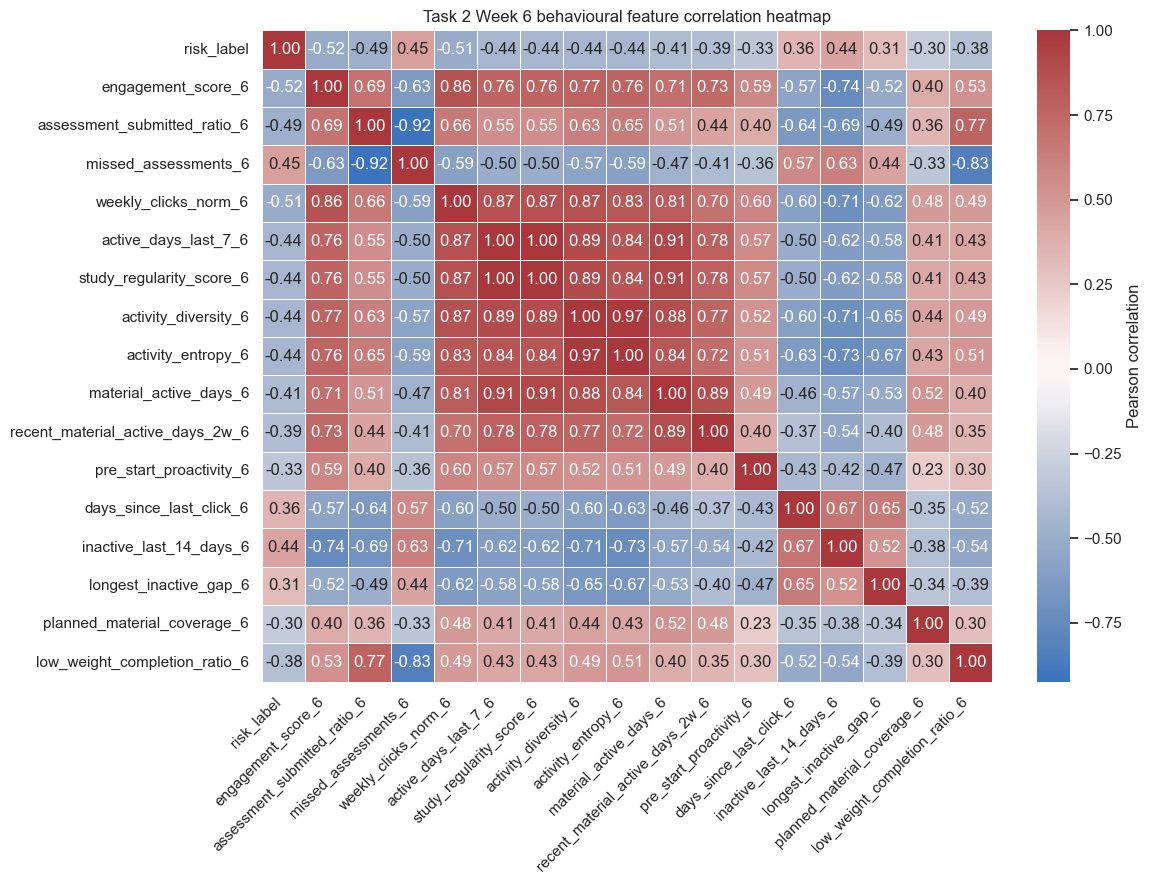

,correlation_with_withdraw_fail
engagement_score_6,-0.516443
weekly_clicks_norm_6,-0.507111
assessment_submitted_ratio_6,-0.485747
missed_assessments_6,0.452782
activity_diversity_6,-0.440968
inactive_last_14_days_6,0.438877
activity_entropy_6,-0.438612
active_days_last_7_6,-0.438598
study_regularity_score_6,-0.438598
material_active_days_6,-0.411011


In [10]:
behavioral_heatmap_features = [
    "risk_label",
    "engagement_score_6",
    "assessment_submitted_ratio_6",
    "missed_assessments_6",
    "weekly_clicks_norm_6",
    "active_days_last_7_6",
    "study_regularity_score_6",
    "activity_diversity_6",
    "activity_entropy_6",
    "material_active_days_6",
    "recent_material_active_days_2w_6",
    "pre_start_proactivity_6",
    "days_since_last_click_6",
    "inactive_last_14_days_6",
    "longest_inactive_gap_6",
    "planned_material_coverage_6",
    "low_weight_completion_ratio_6",
]
behavioral_heatmap_features = [c for c in behavioral_heatmap_features if c in model_df.columns]
heatmap_corr = model_df[behavioral_heatmap_features].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    heatmap_corr,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Task 2 Week 6 behavioural feature correlation heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR.parent / "reports" / "figures" / "task2_behavioral_correlation_heatmap.png", dpi=160)
plt.show()

heatmap_corr["risk_label"].drop("risk_label").sort_values(key=lambda s: s.abs(), ascending=False).to_frame("correlation_with_withdraw_fail")

## 3. Model Selection Evidence And Production Model

The model-selection experiment compared Logistic Regression, Random Forest, XGBoost, and one regularized XGBoost variant. XGBoost had the best validation F1 and recall while keeping ROC-AUC and PR-AUC competitive, so the production pipeline now trains **XGBoost only**. The comparison table is retained below as the evidence for that choice, while the normal pipeline avoids retraining every candidate model on each run. The test set remains held back until after modelling choices are made.

In [11]:
model_result = train_risk_model(model_df, split)

model_result["model_comparison"][[
    "model_name", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc", "selection_threshold", "alerts", "alert_rate"
]]


,model_name,precision,recall,f1,f2,pr_auc,roc_auc,selection_threshold,alerts,alert_rate
0,xgboost,0.738301,0.842244,0.786854,0.819178,0.894913,0.862670,0.370316,14723,0.602315
1,xgboost_regularized,0.752926,0.817449,0.783862,0.803675,0.890855,0.858284,NaN,14012,0.573229
2,random_forest,0.753832,0.815512,0.783460,0.802382,0.890141,0.857402,NaN,13962,0.571183
3,logistic_regression,0.772892,0.793972,0.783290,0.789664,0.892431,0.859010,NaN,13258,0.542383


In [12]:
model_result["overfit_check"][[
    "model_name", "evaluation", "precision", "recall", "f1", "roc_auc", "false_positives", "false_negatives", "alerts", "alert_rate"
]].sort_values(["model_name", "evaluation"])


,model_name,evaluation,precision,recall,f1,roc_auc,false_positives,false_negatives,alerts,alert_rate
1,xgboost,test,0.742073,0.848675,0.791802,0.870063,1269,651,4920,0.603755
0,xgboost,train_fit,0.744154,0.848288,0.792816,0.871593,3764,1958,14712,0.601865


## 4. Final XGBoost Model And Test Metrics

The production classifier is XGBoost, selected from the model-comparison evidence above. The final product decision is not “alert everyone above one aggressive threshold”; instead, predicted risk is converted into capacity-based intervention tiers. This keeps advisor workload realistic while still using the model ranking to prioritize support.

In [13]:
plot_model_outputs(model_result)

print("Cutoff metrics")
pd.DataFrame([
    {"cutoff": "high_touch_20pct", **model_result["primary_metrics"]},
    {"cutoff": "light_touch_60pct", **model_result["watchlist_metrics"]},
    {"cutoff": "capacity_20pct", **model_result["capacity_metrics"]},
])


Cutoff metrics


,cutoff,threshold,precision,recall,f1,f2,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,alerts,alert_rate,confusion_matrix,model_name,threshold_name,selection_rule
0,high_touch_20pct,0.928056,0.991437,0.376801,0.546067,0.430133,0.870063,0.900592,3833,14,2681,1621,1635,0.200638,"[[3833, 14], [2681, 1621]]",xgboost,high_touch_20pct,xgboost_production_model_then_capacity_based_h...
1,light_touch_60pct,0.372273,0.743883,0.847978,0.792527,0.824891,0.870063,0.900592,2591,1256,654,3648,4904,0.601792,"[[2591, 1256], [654, 3648]]",NaN,NaN,NaN
2,capacity_20pct,0.928056,0.991437,0.376801,0.546067,0.430133,0.870063,0.900592,3833,14,2681,1621,1635,0.200638,"[[3833, 14], [2681, 1621]]",NaN,NaN,NaN


<Figure size 500x400 with 0 Axes>

In [14]:
model_result["threshold_table"][[
    "threshold_name", "threshold", "precision", "recall", "f1", "roc_auc", "false_positives", "false_negatives", "alerts", "alert_rate"
]]


,threshold_name,threshold,precision,recall,f1,roc_auc,false_positives,false_negatives,alerts,alert_rate
0,high_touch_20pct,0.928056,0.991437,0.376801,0.546067,0.870063,14,2681,1635,0.200638
1,light_touch_60pct,0.372273,0.743883,0.847978,0.792527,0.870063,1256,654,4904,0.601792
2,cv_max_f1_threshold,0.370316,0.742073,0.848675,0.791802,0.870063,1269,651,4920,0.603755
3,cv_max_f2_threshold,0.175846,0.591222,0.976987,0.736658,0.870063,2906,99,7109,0.872377
4,cv_recall85_threshold,0.360011,0.734157,0.856346,0.790558,0.870063,1334,618,5018,0.615781
5,selected_cv_max_f1,0.370316,0.742073,0.848675,0.791802,0.870063,1269,651,4920,0.603755
6,capacity_10pct,0.993446,1.000000,0.210600,0.347926,0.870063,0,3396,906,0.111179
7,capacity_20pct,0.928056,0.991437,0.376801,0.546067,0.870063,14,2681,1635,0.200638
8,capacity_30pct,0.736972,0.942162,0.549047,0.693788,0.870063,145,1940,2507,0.307645
9,capacity_60pct,0.372273,0.743883,0.847978,0.792527,0.870063,1256,654,4904,0.601792


In [15]:
cm = model_result["primary_metrics"]["confusion_matrix"]
cm_df = pd.DataFrame(cm, index=["Actual pass/distinction", "Actual withdraw/fail"], columns=["Pred pass/distinction", "Pred withdraw/fail"])
cm_df


,Pred pass/distinction,Pred withdraw/fail
Actual pass/distinction,3833,14
Actual withdraw/fail,2681,1621


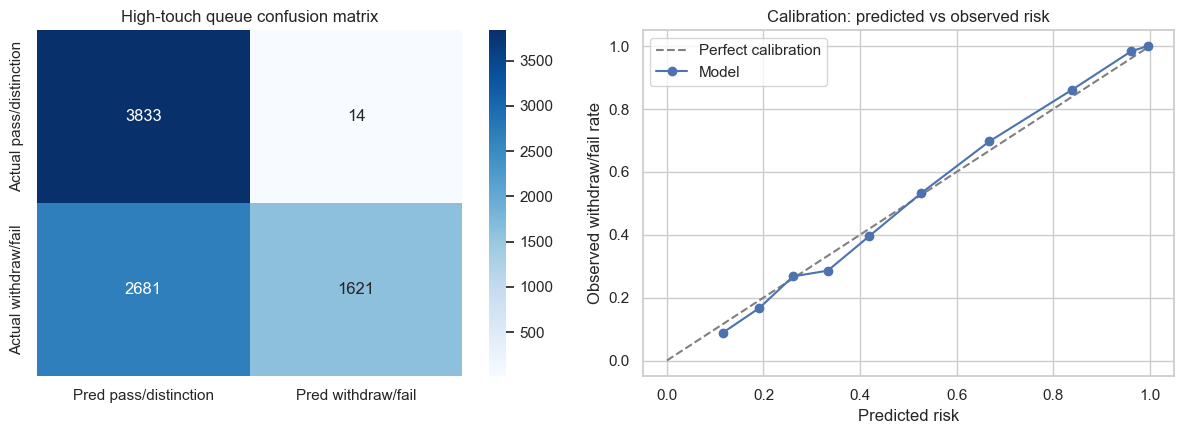

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("High-touch queue confusion matrix")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

calibration = model_result["calibration"]
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1].plot(calibration["mean_predicted_risk"], calibration["observed_risk_rate"], marker="o", label="Model")
axes[1].set_title("Calibration: predicted vs observed risk")
axes[1].set_xlabel("Predicted risk")
axes[1].set_ylabel("Observed withdraw/fail rate")
axes[1].legend()
plt.tight_layout()


## 5. Top Feature Drivers

Permutation importance is used so that the explanation works for both linear and non-linear models. A larger AUC drop means the model relied more on that feature.


In [17]:
model_result["feature_drivers"].head(12)


,feature,auc_drop,recall_drop
48,avg_score_so_far_6,0.036552,0.018596
29,first_click_day_6,0.021439,-0.017434
49,engagement_score_6,0.014444,-0.032543
1,weekly_clicks_norm_6,0.008853,-0.016272
107,education_x_assessment_completion,0.008391,-0.017666
57,module_code,0.006692,-0.001627
36,assessment_submitted_ratio_6,0.003627,-0.013017
106,credits_x_low_engagement,0.002765,-0.013947
89,imd_midpoint,0.002113,0.004417
47,starting_early_score_6,0.001015,-0.004417


In [18]:
model_result["behavioral_feature_drivers"].head(8)


,feature,auc_drop,recall_drop
0,engagement_score_6,0.014444,-0.032543
1,weekly_clicks_norm_6,0.008853,-0.016272
2,assessment_submitted_ratio_6,0.003627,-0.013017
3,imd_midpoint,0.002113,0.004417
4,starting_early_score_6,0.001015,-0.004417
5,late_submission_count_6,0.000764,0.002557
6,days_since_last_click_6,0.000220,-0.000232
7,education_level_ord,0.000181,-0.000232


## 6. Intervention Design

The staff notification should be more than a probability, but it should also avoid alert fatigue. The model output is therefore split into three tiers:

- **High-touch support queue:** top 10-20% risk, prioritized for human advisor intervention.
- **Light-touch behavioural nudges:** next 30-40% risk, handled through automated reminders, study-planning prompts, and resource suggestions.
- **Monitoring:** remaining students, no immediate intervention unless risk rises later.

An advisor receives student, module, presentation, intervention tier, predicted risk percentage, engagement trajectory, top behavioural drivers, and suggested action. This framing makes the model operationally credible: the highest-risk students receive scarce advisor time, while broader risk signals still trigger low-cost support.
